In [51]:
!pip install spacy PyPDF2

In [52]:
import spacy

try:
    nlp = spacy.load("es_core_news_sm")
except:
    from spacy.cli import download
    download("es_core_news_sm")

print("Modelo cargado correctamente")

Modelo cargado correctamente


In [53]:
from google.colab import files

uploaded = files.upload()

Saving EBOOK-GLOSARIO-DE-PROGRAMACION-Curso-de-Desarrollo-con-IA-1.pdf to EBOOK-GLOSARIO-DE-PROGRAMACION-Curso-de-Desarrollo-con-IA-1.pdf


In [55]:
!pip install PyPDF2
import PyPDF2

nombre_archivo = "EBOOK-GLOSARIO-DE-PROGRAMACION-Curso-de-Desarrollo-con-IA-1.pdf"

with open(nombre_archivo, "rb") as archivo:
    lector = PyPDF2.PdfReader(archivo)

    texto = ""
    for pagina in lector.pages:
        texto += pagina.extract_text()

print(texto[:1000])

términos más
utilizados en
programación 
Los   
200A 
A lg oritm o  
A nálisis de C om plejidad  
A PI (A pplic ation Prog ram m ing  Interfac e) A PI
G raph QL 
A PI K ey 
A PI RESTfu l 
A rg u m ento 
A rray (A rreg lo) 
A tribu to  
B 
BaaS (Bac k end as a Servic e)  
Bac k end 
Balanc eador de c arg a (L oad Balanc er) Balanc eo
de c arg a 
Base de datos  
Batc h  Proc essing  (Proc esam iento por lotes)
Bibliotec a o L ibrería (L ibrary)  
Big  Data 
Big  O 
Binario  
Bit  
Booleano 
Bu c les (L oops) 
Bu ffer 
Bu g 
Bu ild (C om pilac ión)  
C 
C ac h e 
C allbac k 
C arg a (L oad) 
C lase (C lass)  
C L I (C om m and-line interfac e) 2 
9
9
9
9
9
10
10
10
10
10
11
11
11
11
11
11
12
12
12
12
12
12
13
13
13
13
13
14
14
14
14
14
14 Índice E
Efic ienc ia
Elem ento
Enc apsu lac ión C losu re (C lau su ra) 
C ódig o fu ente (Sou rc e c ode) 
C ódig o lim pio (C lean C ode)  
C ola (Qu eu e) 
C om m it 
C om pilac ión (Bu ild)  
C om pilador  
C om pilador Ju st-in-Tim e (JIT) 
C om pr

In [56]:
texto_limpio = " ".join(texto.split())

# separar palabras por espacios
palabras = texto_limpio.split(" ")

# quedarnos con palabras que parecen términos (empiezan en mayúscula)
terminos = [p for p in palabras if p[:1].isupper()]

# quitar duplicados
terminos_unicos = list(set(terminos))

# mostrar algunos
print(terminos_unicos[:50])

['Iteración', 'Qu', 'Paradig', 'Diagramas', 'Null', 'Notation)', 'Garbage', 'F', 'PI', 'Encriptación', 'Inyec', 'Read,', 'Stack', 'TI', 'Token)', 'OA', 'V', 'Glosario', 'Diag', 'Estru', 'UTF', 'Red', 'Variable', 'DevOps', 'Protoc', 'Tipo', 'Mide', 'Overflow)', 'Cola', 'Medida', 'Sharing)', 'Namespace', 'Automático)', 'Sínc', 'Parám', 'Control)', 'Objetos)', 'JavaScript', 'CRUD', 'Java', 'Runtime', 'Firewall', 'ANo', 'M', 'Expresión', 'Tok', 'Z-index', 'JavaSc', 'ETE)', 'Update,']


In [57]:
import spacy

try:
    nlp = spacy.load("es_core_news_sm")
except:
    from spacy.cli import download
    download("es_core_news_sm")
    nlp = spacy.load("es_core_news_sm")

doc = nlp(texto_limpio)

tokens = [token.text for token in doc]

print("Total tokens:", len(tokens))
print(tokens[:40])

Total tokens: 11944
['términos', 'más', 'utilizados', 'en', 'programación', 'Los', '200A', 'A', 'lg', 'oritm', 'o', 'A', 'nálisis', 'de', 'C', 'om', 'plejidad', 'A', 'PI', '(', 'A', 'pplic', 'ation', 'Prog', 'ram', 'm', 'ing', 'Interfac', 'e', ')', 'A', 'PI', 'G', 'raph', 'QL', 'A', 'PI', 'K', 'ey', 'A']


In [58]:
tokens_limpios = []

for token in doc:
    if not token.is_stop and not token.is_punct and token.text.strip():
        tokens_limpios.append(token.lemma_.lower())

print("Total tokens limpios:", len(tokens_limpios))
print(tokens_limpios[:40])

Total tokens limpios: 7709
['término', 'utilizado', 'programación', '200a', 'lg', 'oritm', 'nálisis', 'c', 'om', 'plejidad', 'pi', 'pplic', 'ation', 'prog', 'ram', 'm', 'ing', 'interfac', 'pi', 'g', 'raph', 'ql', 'pi', 'k', 'ey', 'pi', 'restfu', 'l', 'rg', 'm', 'ento', 'rray', 'rreg', 'tribu', 'to', 'b', 'baas', 'bac', 'k', 'end']


In [59]:
import pandas as pd
from nltk.stem import SnowballStemmer

stemmer = SnowballStemmer("spanish")

data = []

for token in doc[:200]:  # solo muestra parte para no saturar
    if token.is_punct or token.is_space:
        continue

    data.append({
        "Original": token.text,
        "Lema": token.lemma_,
        "Stem": stemmer.stem(token.text)
    })

df = pd.DataFrame(data)

df.head(20)

,Original,Lema,Stem
0,términos,término,termin
1,más,más,mas
2,utilizados,utilizado,utiliz
3,en,en,en
4,programación,programación,program
5,Los,el,los
6,200A,200a,200a
7,A,A,a
8,lg,lg,lg
9,oritm,oritm,oritm


In [60]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [61]:
for oracion in doc.sents:
    lemas_oracion = [
        token.lemma_.lower()
        for token in oracion
        if not token.is_punct and not token.is_space and not token.is_stop
    ]
    if lemas_oracion:
        corpus_lematizado.append(" ".join(lemas_oracion))

print(f"Total de oraciones procesadas: {len(corpus_lematizado)}")

Total de oraciones procesadas: 1128


In [62]:


# BoW
bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(corpus_lematizado)
vocab_bow = bow_vectorizer.get_feature_names_out()

print("\n--- Bag of Words ---")
print("Dimensión:", X_bow.shape)

# TF-IDF
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(corpus_lematizado)
vocab_tfidf = tfidf_vectorizer.get_feature_names_out()

print("\n--- TF-IDF ---")
print("Dimensión:", X_tfidf.shape)


--- Bag of Words ---
Dimensión: (1128, 1531)

--- TF-IDF ---
Dimensión: (1128, 1531)


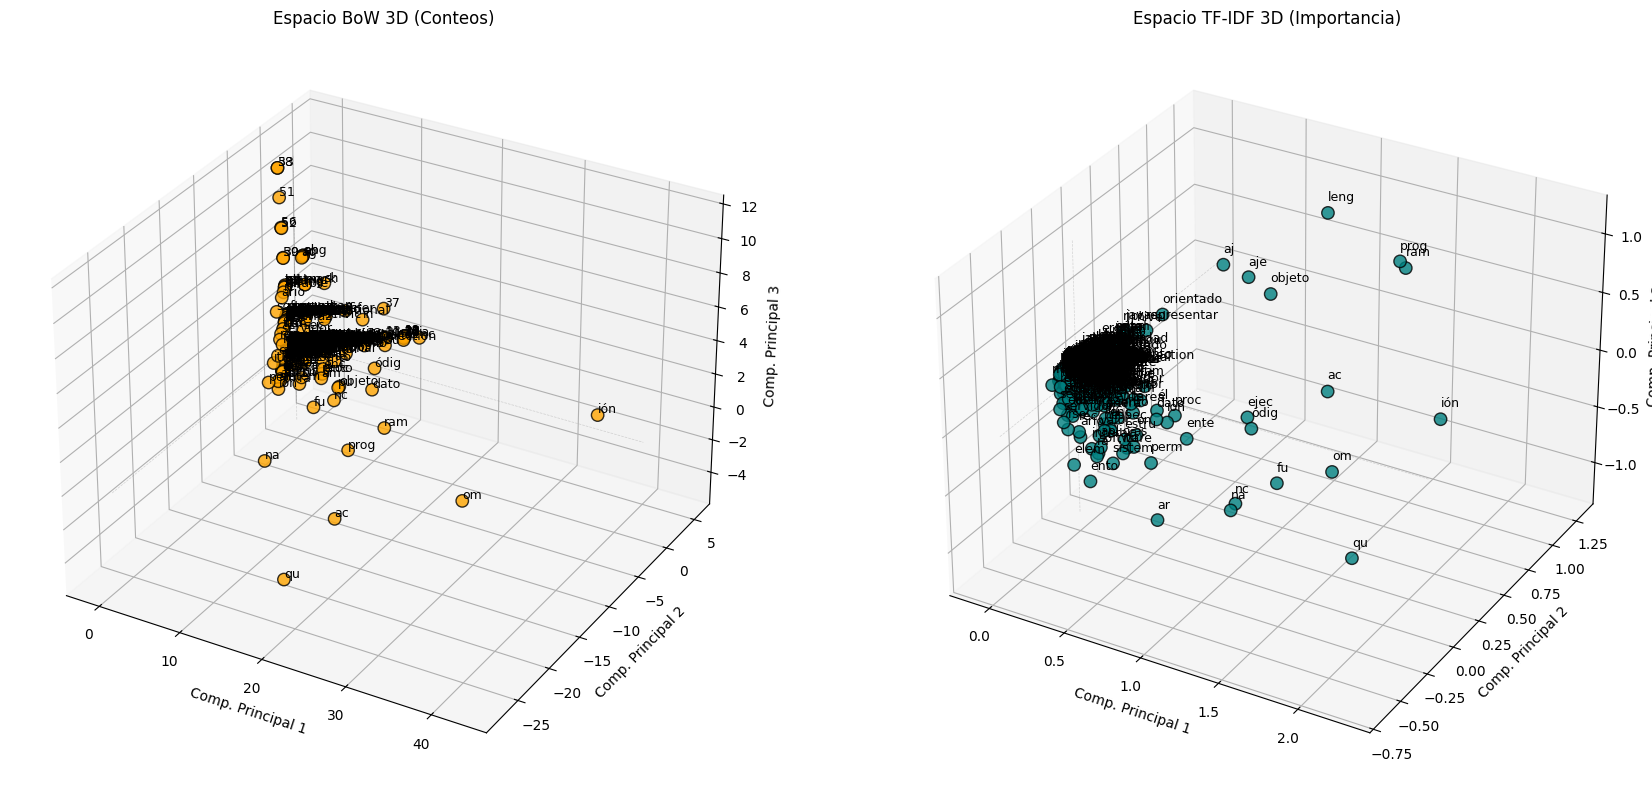

In [63]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Import necesario para 3D
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
import numpy as np

# ---------------------------------------------------------
# FUNCIÓN AUXILIAR PARA GRAFICAR EN 3D
# ---------------------------------------------------------
def graficar_palabras_3d(ax, matriz, vocabulario, titulo, color_puntos):
    # 1. TRANSPONER: Filas = Palabras, Columnas = Contextos
    matriz_palabras = matriz.T

    # 2. PCA: Reducir a 3 DIMENSIONES
    pca = PCA(n_components=3)
    coords = pca.fit_transform(matriz_palabras.toarray())

    # Extraer coordenadas X, Y, Z
    x = coords[:, 0]
    y = coords[:, 1]
    z = coords[:, 2]

    # 3. GRAFICAR SCATTER 3D
    # Usamos profundidad visual (depthshade=True) para ayudar a la perspectiva
    ax.scatter(x, y, z, c=color_puntos, s=80, edgecolors='k', alpha=0.8, depthshade=True)

    # Etiquetar puntos
    for i, palabra in enumerate(vocabulario):
        # Agregamos un pequeño offset a Z para que el texto flote sobre el punto
        ax.text(x[i], y[i], z[i] + 0.1, palabra, fontsize=9)

    ax.set_title(titulo)
    ax.set_xlabel('Comp. Principal 1')
    ax.set_ylabel('Comp. Principal 2')
    ax.set_zlabel('Comp. Principal 3')

    # Líneas de referencia en el origen (0,0,0)
    ax.plot([0,0], [0,0], [z.min(), z.max()], c='grey', ls='--', lw=0.5, alpha=0.3)
    ax.plot([x.min(), x.max()], [0,0], [0,0], c='grey', ls='--', lw=0.5, alpha=0.3)
    ax.plot([0,0], [y.min(), y.max()], [0,0], c='grey', ls='--', lw=0.5, alpha=0.3)


# ---------------------------------------------------------
# CONFIGURACIÓN DE LA FIGURA 3D
# ---------------------------------------------------------
# Creamos una figura ancha para poner dos gráficos lado a lado
fig = plt.figure(figsize=(18, 8))

# --- A. BAG OF WORDS (Izquierda) ---
# subplot(filas, columnas, índice, proyección)
ax1 = fig.add_subplot(121, projection='3d')

bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(corpus_lematizado)
vocab_bow = bow_vectorizer.get_feature_names_out()

graficar_palabras_3d(ax1, X_bow, vocab_bow,
                     "Espacio BoW 3D (Conteos)",
                     "orange")

# --- B. TF-IDF (Derecha) ---
ax2 = fig.add_subplot(122, projection='3d')

tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(corpus_lematizado)
vocab_tfidf = tfidf_vectorizer.get_feature_names_out()

graficar_palabras_3d(ax2, X_tfidf, vocab_tfidf,
                     "Espacio TF-IDF 3D (Importancia)",
                     "teal")

plt.tight_layout()
plt.show()

In [64]:
!ls

'EBOOK-GLOSARIO-DE-PROGRAMACION-Curso-de-Desarrollo-con-IA-1 (1).pdf'
 EBOOK-GLOSARIO-DE-PROGRAMACION-Curso-de-Desarrollo-con-IA-1.pdf
 README.md
 sample_data


In [66]:
!rm -rf sample_data

In [67]:
!rm "EBOOK-GLOSARIO-DE-PROGRAMACION-Curso-de-Desarrollo-con-IA-1 (1).pdf"
!rm "EBOOK-GLOSARIO-DE-PROGRAMACION-Curso-de-Desarrollo-con-IA-1.pdf"

In [68]:
!ls

README.md


In [69]:
!ls


README.md


In [ ]:
!ls

